# Proyek Klasifikasi Gambar: Brain Tumor MRI
- **Nama:** Nadila Agustiani Farhan
- **Email:** nadilaagustiani1010@gmail.com
- **ID Dicoding:** MC171D5X0647


Proyek ini mengambil dataset brain tumor MRI untuk mengklasifikasikan hasil MRi yang menunjukan jenis-jenis Tumor otak, diantaranya
- Glioma
Jenis tumor otak primer yang berasal dari jarningan otak.
- Meningioma
Jenis tumor yang bersifat jinak dan pertumbuhannya lambat, terbentu di meninges, yaitu selaput pelindung otak dan saraf tulang belakang.
- No tumor
Kondisi otak yang normal tidak ada indikasi tumor
- Pituitari
Tumor yang tumbuh di kelenjar pituitary, bersifat jinak atau non-kanker

In [1]:
!pip install tensorflowjs
!pip install tensorflow keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


##Import Semua Packages/library yang Digunakan

In [44]:
# Library yang sering digunakan
import os, shutil
import zipfile
from shutil import copyfile
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Libraries untuk pemrosesan data gambar
import random
import cv2
from PIL import Image
import skimage
import io

# Librari untuk pembangunan model
#Library yang berkaitan dengan pembuatan model dan evaluasi model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import Callback

In [4]:
# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

##Data Preparation

### Data Loading
Download dataset dari kaggle

In [5]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tombackert/brain-tumor-mri-data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data
License(s): MIT


In [6]:
# Unzip dataset
!unzip brain-tumor-mri-data.zip

Streaming output truncated to the last 5000 lines.
  inflating: brain-tumor-mri-dataset/meningioma/me-0533.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0534.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0535.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0536.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0537.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0538.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0539.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0540.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0541.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0542.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0543.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0544.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0545.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0546.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0547.jpg  
  inflating: brain-

In [7]:
# Memeriksa jumlah file pada dataset
BASE_DIR = '/content/brain-tumor-mri-dataset'
class_counts = {}
for class_name in os.listdir(BASE_DIR):
    class_dir = os.path.join(BASE_DIR, class_name)
    if os.path.isdir(class_dir):
        jpg_files = [f for f in os.listdir(class_dir)]
        class_counts[class_name] = len(jpg_files)

# Tampilkan hasil
for class_name, count in class_counts.items():
    print(f"Class: {class_name}, Jumlah Gambar : {count}")

Class: glioma, Jumlah Gambar : 1621
Class: pituitary, Jumlah Gambar : 1757
Class: meningioma, Jumlah Gambar : 1775
Class: notumor, Jumlah Gambar : 2000


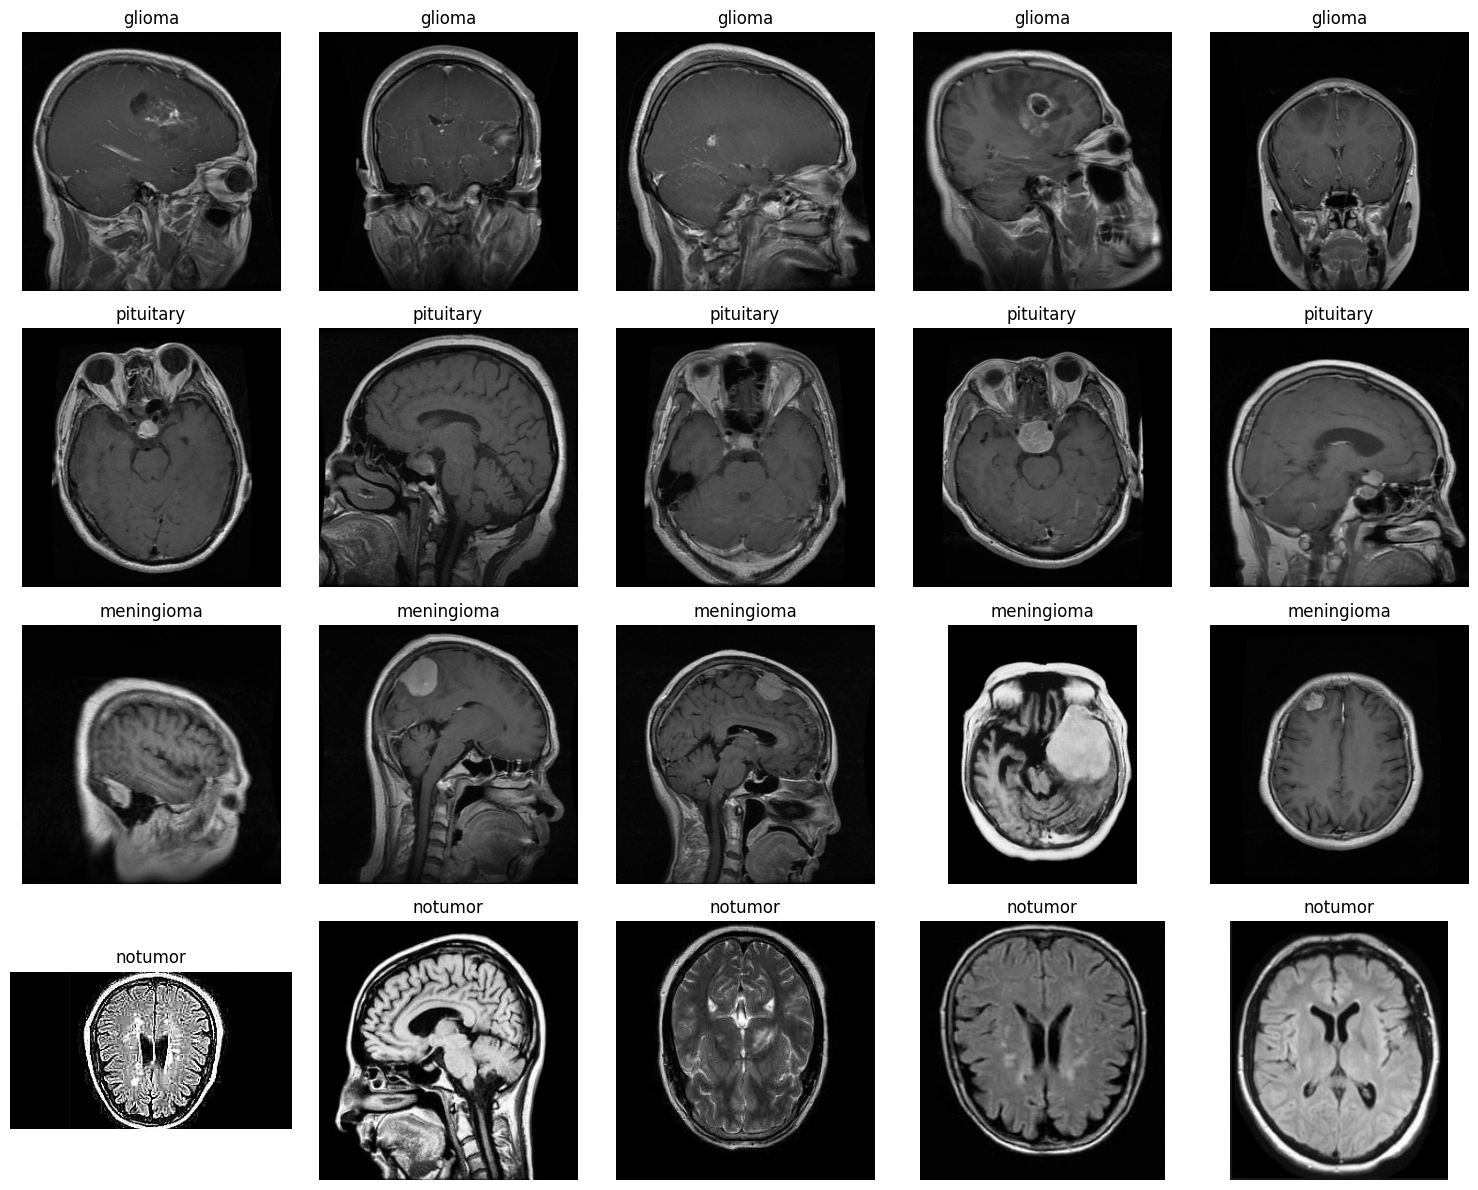

In [9]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas
lung_image = {}

# Path dataset baru
path_sub = "/content/brain-tumor-mri-dataset"

# Mengisi dictionary dengan file gambar dari setiap kelas
for class_name in os.listdir(path_sub):
    class_path = os.path.join(path_sub, class_name)
    if os.path.isdir(class_path):
        # Ambil hanya file gambar (png, jpg, jpeg)
        image_files = [f for f in os.listdir(class_path)]
        if image_files:  # hanya kalau ada file gambarnya
            lung_image[class_name] = image_files

# Menampilkan 5 gambar acak dari tiap kelas
fig, axs = plt.subplots(len(lung_image), 5, figsize=(15, 3 * len(lung_image)))

for i, class_name in enumerate(lung_image.keys()):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set_title(class_name)
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()


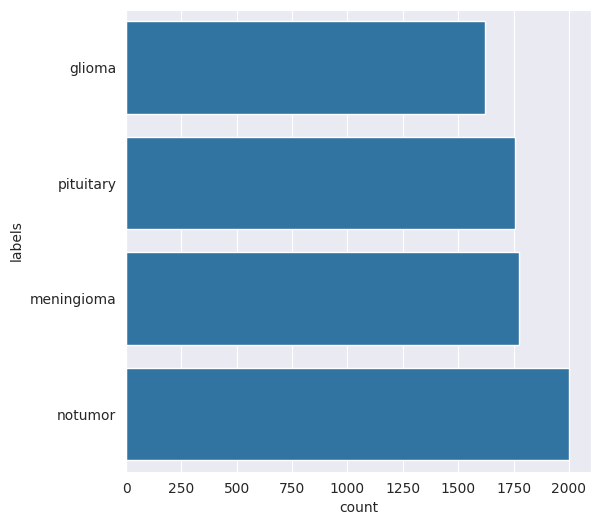

In [11]:
# Melihat grafik tiap kelas
import seaborn as sns

lung_path = "/content/brain-tumor-mri-dataset"

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

###Data Spliting

In [14]:
# Path dataset asli
source_dir = '/content/brain-tumor-mri-dataset'

# Path output (folder akan otomatis dibuat)
output_dir = '/content/brain_tumor_split'
splits = ['train', 'val', 'test']
split_ratios = [0.8, 0.1, 0.1]  # 80% train, 10% val, 10% test

# Membuat folder tujuan untuk setiap split dan kelas
for split in splits:
    for class_name in os.listdir(source_dir):
        split_class_dir = os.path.join(output_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

# Memindahkan gambar sesuai split
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratios[0] * total)
    val_end = train_end + int(split_ratios[1] * total)

    split_data = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split in splits:
        for img in split_data[split]:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_dir, split, class_name, img)
            shutil.copy2(src, dst)

print("Dataset berhasil dibagi ke dalam train (80%), val (10%), dan test (10%)!")

Dataset berhasil dibagi ke dalam train (80%), val (10%), dan test (10%)!


In [15]:
# Lokasi folder hasil pembagian manual
train_dir = '/content/brain_tumor_split/train'
val_dir = '/content/brain_tumor_split/val'
test_dir = '/content/brain_tumor_split/test'

base_dir = 'brain_tumor_split'
img_size = (150, 150)
batch_size = 32

#Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Validation set
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'val'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

#Test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 5721 files belonging to 4 classes.
Found 714 files belonging to 4 classes.
Found 718 files belonging to 4 classes.


In [30]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

##Modeling

In [31]:
model = tf.keras.models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,496,100 (36.22 MB)

 Trainable params: 9,496,100 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Membuat callback
class StopTrainingAtAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target_acc=0.95):
        super().__init__()
        self.target_acc = target_acc

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("accuracy")
        if acc is not None and acc >= self.target_acc:
            print(f"\nAkurasi sudah mencapai {acc:.2%}, menghentikan pelatihan.")
            self.model.stop_training = True

# Membuat objek callback
stop_acc_callback = StopTrainingAtAccuracy(target_acc=0.95)

# Training model
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[stop_acc_callback]
)

Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 148s 811ms/step - accuracy: 0.5949 - loss: 0.9642 - val_accuracy: 0.8389 - val_loss: 0.4166
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 138s 767ms/step - accuracy: 0.8358 - loss: 0.4216 - val_accuracy: 0.9062 - val_loss: 0.2763
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 770ms/step - accuracy: 0.9023 - loss: 0.2587 - val_accuracy: 0.9300 - val_loss: 0.2140
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.9454 - loss: 0.1518
Akurasi sudah mencapai 95.23%, menghentikan pelatihan.
179/179 ━━━━━━━━━━━━━━━━━━━━ 139s 774ms/step - accuracy: 0.9455 - loss: 0.1517 - val_accuracy: 0.9384 - val_loss: 0.1784


## Evaluasi dan Visualisasi

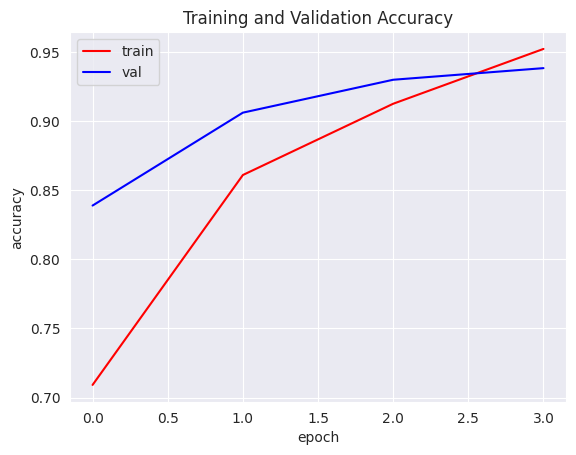

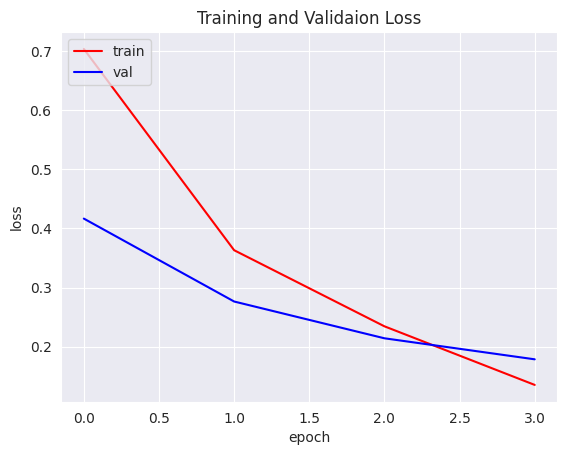

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [34]:
# Menilai model
train_loss, train_acc = model.evaluate(train_ds)
print(f"Akurasi Data Latih: {train_acc:.2%}")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Akurasi Data Uji: {test_acc:.2%}")

179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.9782 - loss: 0.0715
Akurasi Data Latih: 98.04%
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.9200 - loss: 0.2302
Akurasi Data Uji: 91.92%


## Konversi Model

In [35]:
# Save model
tf.saved_model.save(model, 'saved_model')

In [56]:
# Menyimpan model sebagai tflite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

os.makedirs('tflite', exist_ok=True)
with open('tflite/model.tflite', 'wb') as f:
    f.write(converter.convert())

with open('tflite/label.txt', 'w') as f:
    f.write("Cat\nDog\n")

Saved artifact at '/tmp/tmp9fv789a2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_71')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136316523766096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523767632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523767248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523768592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523768016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523769360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523768784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523770320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523769552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136316523770896: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [39]:
# Menyimpan model sebagai tfjs
!tensorflowjs_converter --input_format=tf_saved_model saved_model tfjs_model

2025-05-03 15:54:33.020549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746287673.076869   18927 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746287673.095376   18927 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-03 15:54:44.338334: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1746287684.913085   18927 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00

In [46]:
!pip freeze > requirements.txt

In [50]:
!zip -r tfjs_model.zip tfjs_model

  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard3of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard9of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard5of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard6of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard10of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard4of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard1of10.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 89%)
  adding: tfjs_model/group1-shard2of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard8of10.bin (deflated 7%)
  adding: tfjs_model/group1-shard7of10.bin (deflated 7%)


In [53]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 62%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 10%)
  adding: saved_model/saved_model.pb (deflated 87%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/fingerprint.pb (stored 0%)
